<a href="https://colab.research.google.com/github/Arif1234-cpu/Traffic_Sign_Detection_usingYOLOv8/blob/main/Road_Sign_Detection_System_using_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Access/Enable GPU for Fast processing

In [1]:
import os

if 'COLAB_GPU' in os.environ:
  print("GPU is enabled")
else:
  print("GPU is not enabled!")

GPU is enabled


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.3 MB/s eta 0:00:00


In [3]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [4]:
%pwd

'/content'

In [5]:
!mkdir RoadSignDetection

In [6]:
path = "/content/RoadSignDetection"

In [7]:
%pwd

'/content'

In [8]:
os.chdir("/content/RoadSignDetection")

In [9]:
%pwd

'/content/RoadSignDetection'

In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="MVHFbpXmXy621Dy0AbqM")
project = rf.workspace("selfdriving-car-qtywx").project("self-driving-cars-lfjou")
version = project.version(6)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 138.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Cars-6 in yolov8:: 100%|██████████| 9950/9950 [00:01<00:00, 9213.46it/s] 


# Train the YOLOv8 over Custom Dataset

In [11]:
os.chdir("/content/RoadSignDetection/Self-Driving-Cars-6")

In [12]:
!yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=10 imgsz=640 batch=16

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False,

In [13]:
!ls '/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train'

args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


In [20]:
resultData = '/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train/'
from IPython.display import Image,display

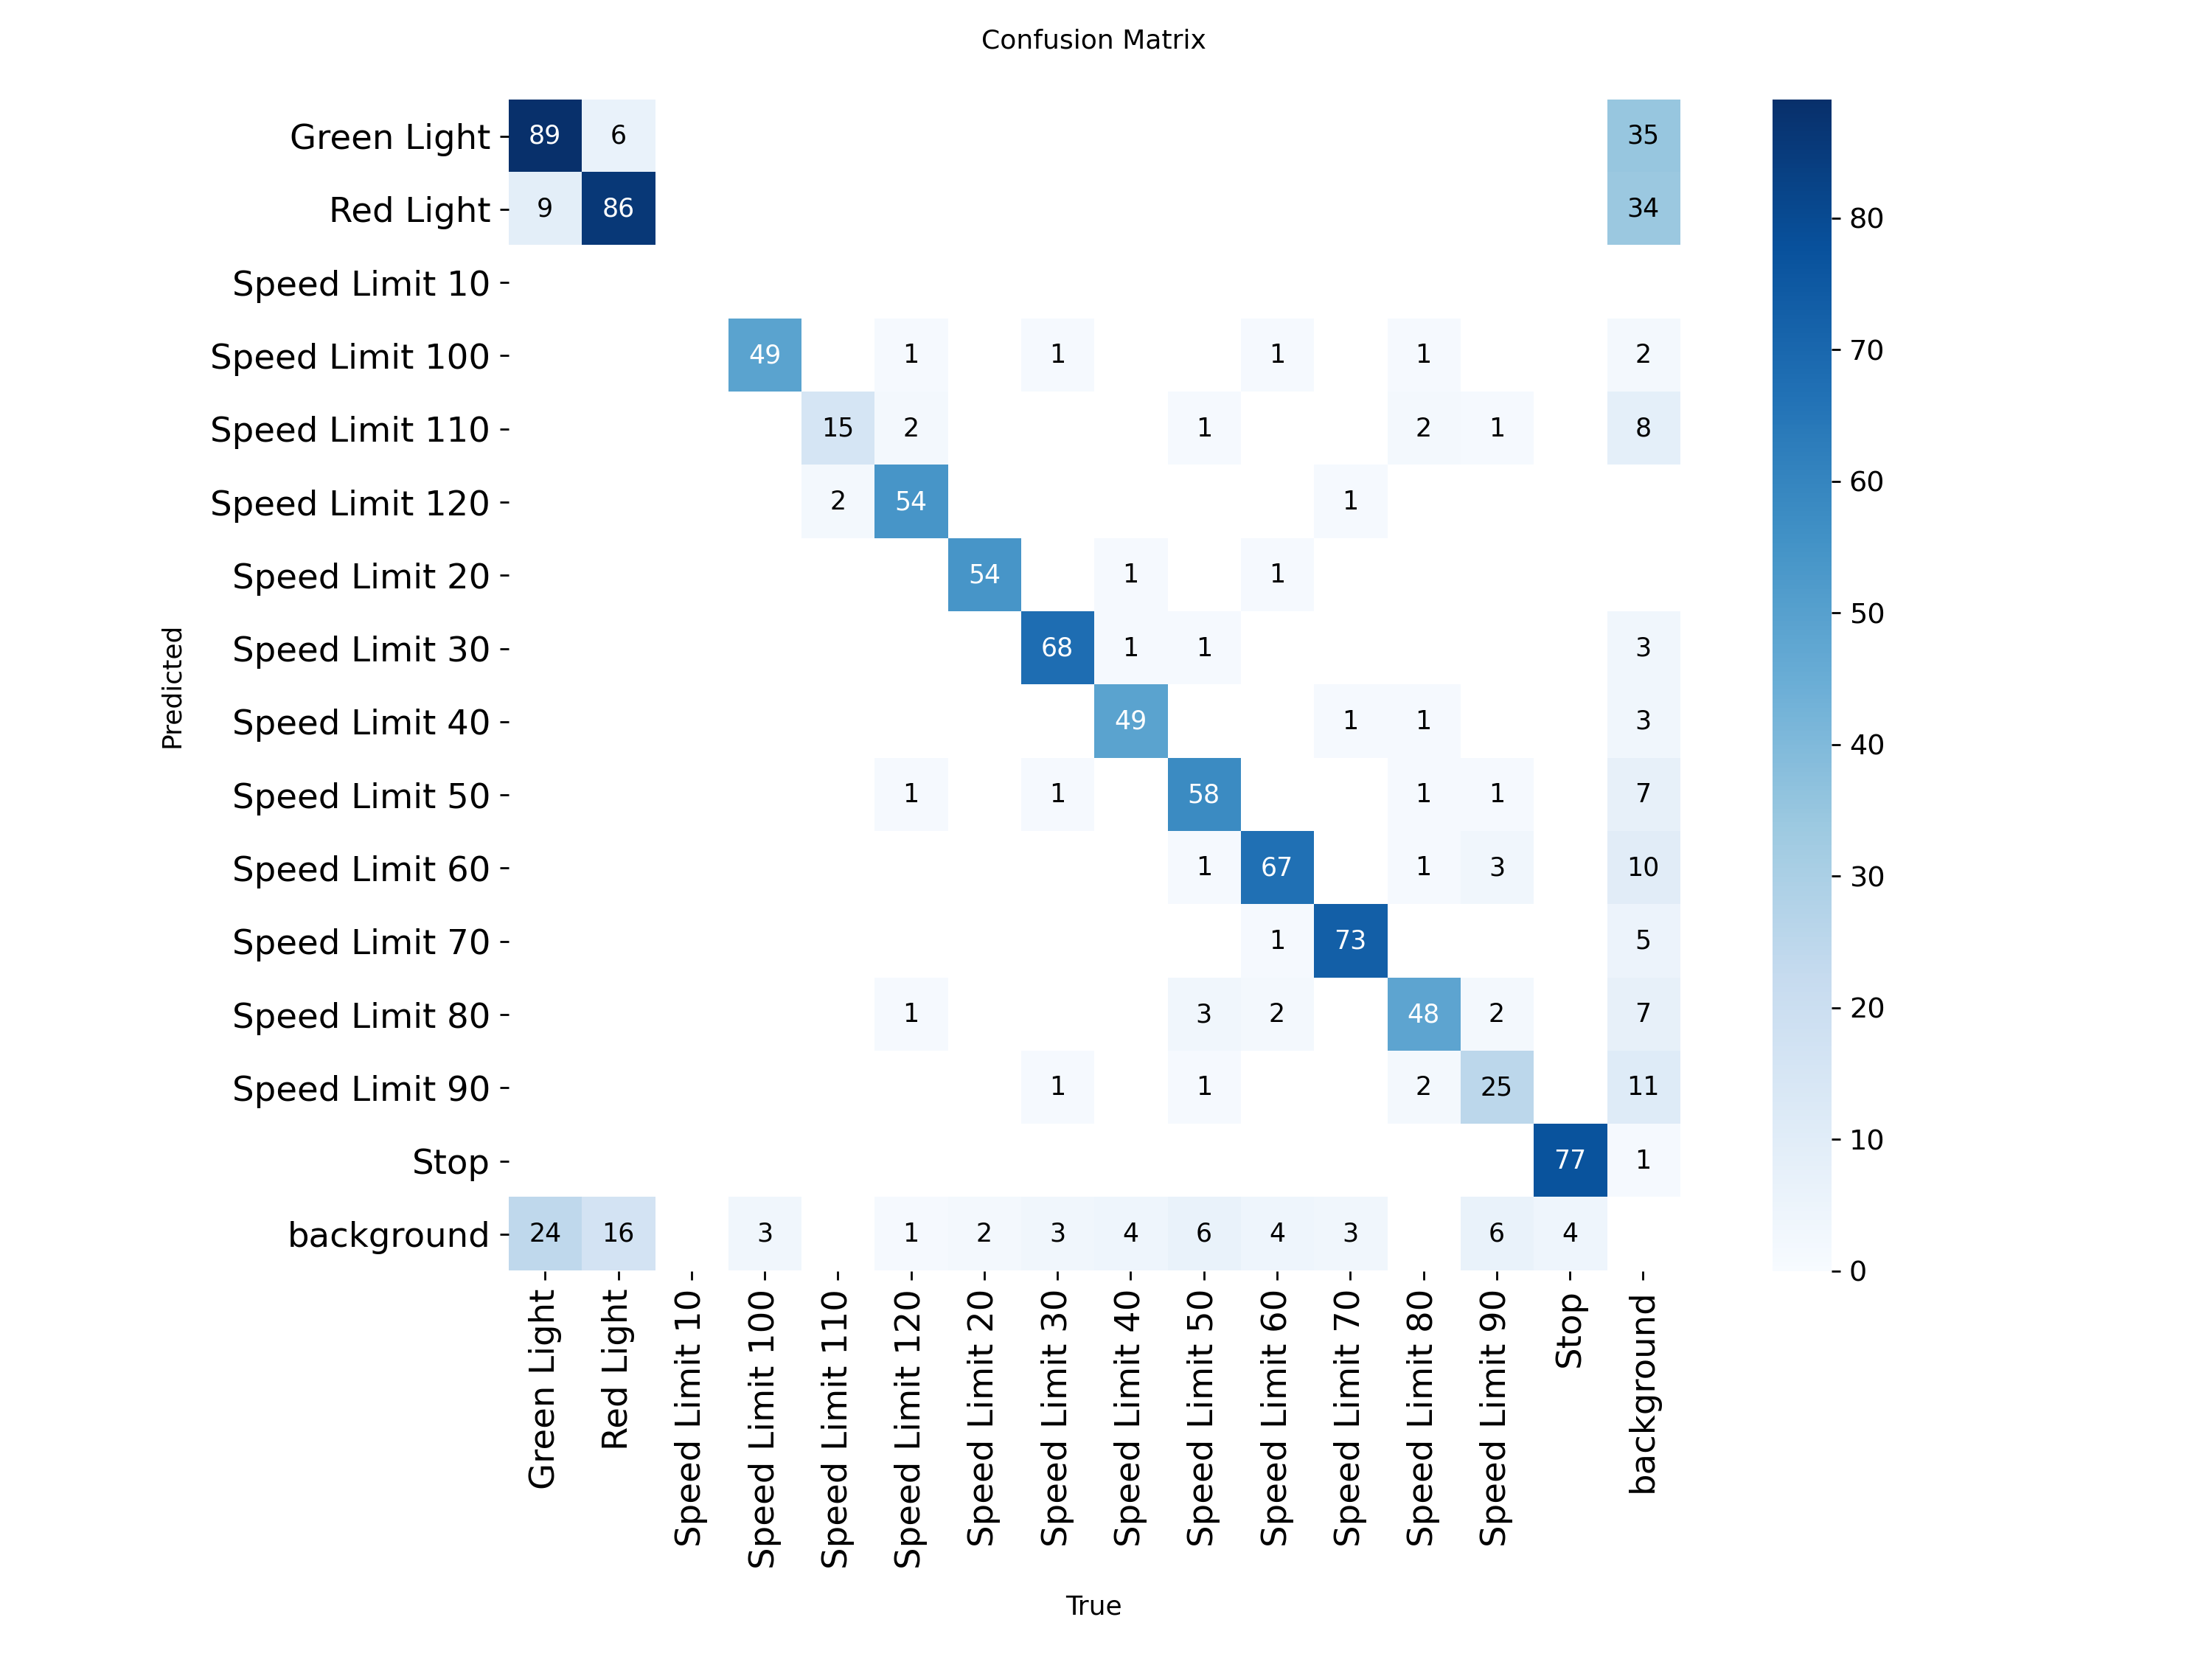

In [22]:
Image(filename = f'{resultData}confusion_matrix.png')

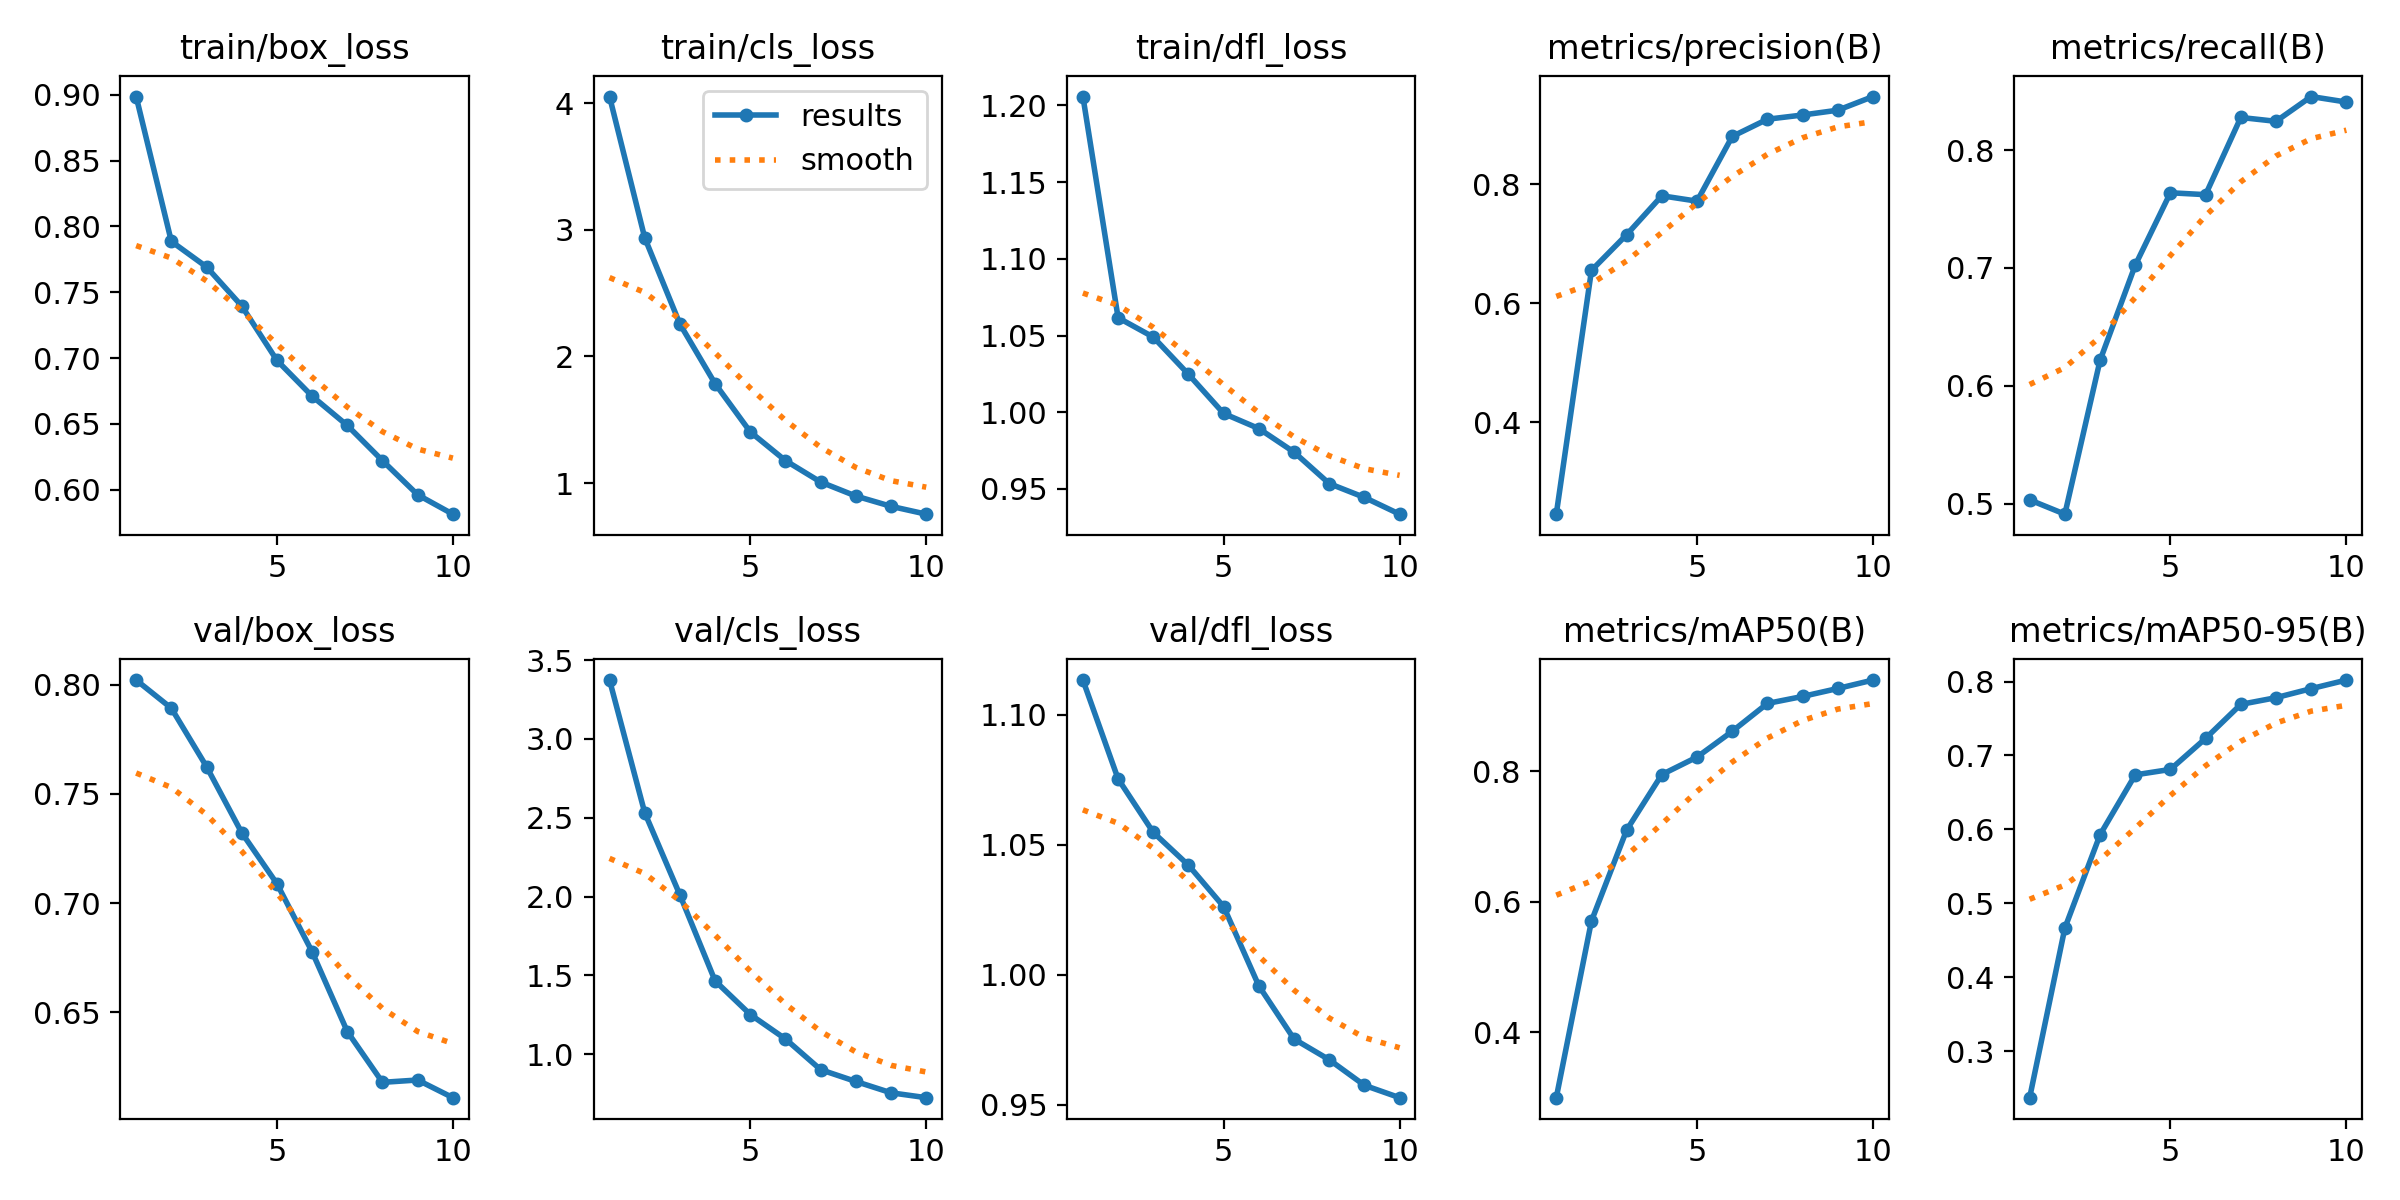

In [23]:
Image(filename = f'{resultData}results.png')

# Validate the Model

In [24]:
%pwd

'/content/RoadSignDetection/Self-Driving-Cars-6'

In [25]:
os.chdir("/content")

In [26]:
!mkdir ManualTestingData

In [27]:
os.chdir('/content/ManualTestingData')

In [30]:
URL = "https://drive.google.com/file/d/1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY/view?usp=sharing"
id = "1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY"

!wget -O inputVideo1.mp4 "https://docs.google.com/uc?export=download&id=1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY"

--2026-08-30 11:09:33--  https://docs.google.com/uc?export=download&id=1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY
Resolving docs.google.com (docs.google.com)... 74.125.143.102, 74.125.143.139, 74.125.143.138, ...
Connecting to docs.google.com (docs.google.com)|74.125.143.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY&export=download [following]
--2026-08-30 11:09:34--  https://drive.usercontent.google.com/download?id=1pfcH9WBbqtellKJPHCCxEhQM_KcUT1wY&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.156.132, 2a00:1450:4013:c1c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.156.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6056799 (5.8M) [video/mp4]
Saving to: ‘inputVideo1.mp4’

inputVideo1.mp4     100%[===================>]   5.78M  13.7MB/s    in 0.4s    



In [32]:
weightsPath = "/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train/weights"

!yolo task=detect mode=predict model={weightsPath}/best.pt conf=.25 source='inputVideo1.mp4' save=True



Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

video 1/1 (frame 1/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 6.3ms
video 1/1 (frame 2/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 8.9ms
video 1/1 (frame 3/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 10.0ms
video 1/1 (frame 4/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 9.6ms
video 1/1 (frame 5/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 9.7ms
video 1/1 (frame 6/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 8.7ms
video 1/1 (frame 7/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 10.9ms
video 1/1 (frame 8/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 9.6ms
video 1/1 (frame 9/283) /content/ManualTestingData/inputVideo1.mp4: 384x640 1 Stop, 8.5ms
video 1/1 (frame 10/283

In [34]:
URL = 'https://drive.google.com/file/d/14UlRoW_8SjUNJdwaP4kQw02SndxYmCmq/view?usp=sharing'
id = '14UlRoW_8SjUNJdwaP4kQw02SndxYmCmq'

!wget -O inputImage.png "https://docs.google.com/uc?export=download&id={id}"



--2026-08-30 11:30:07--  https://docs.google.com/uc?export=download&id=14UlRoW_8SjUNJdwaP4kQw02SndxYmCmq
Resolving docs.google.com (docs.google.com)... 108.177.127.138, 108.177.127.102, 108.177.127.113, ...
Connecting to docs.google.com (docs.google.com)|108.177.127.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=14UlRoW_8SjUNJdwaP4kQw02SndxYmCmq&export=download [following]
--2026-08-30 11:30:07--  https://drive.usercontent.google.com/download?id=14UlRoW_8SjUNJdwaP4kQw02SndxYmCmq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.156.132, 2a00:1450:4013:c1c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.156.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 705560 (689K) [image/png]
Saving to: ‘inputImage.png’

inputImage.png      100%[===================>] 689.02K  --.-KB/s    in 0.01s   

In [35]:
!yolo task=detect mode=predict model={weightsPath}/best.pt conf=.25 source='inputImage.png' save=True

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/ManualTestingData/inputImage.png: 352x640 1 Speed Limit 40, 6.7ms
Speed: 47.3ms preprocess, 6.7ms inference, 18.5ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/ManualTestingData/runs/detect/predict-3
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [36]:
from google.colab import files
files.download('/content/ManualTestingData/inputVideo1.mp4')
files.download('/content/ManualTestingData/inputImage.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>